# KLSE Index Movement Classification Using LSTM

This notebook demonstrates building a binary classifier that predicts whether the next trading-day closing price of the Kuala Lumpur Stock Exchange (KLSE) index will move up (1) or stay the same / move down (0).

High-level parts (so you can run and review step-by-step):

1. Setup & Imports
2. Data download
3. Data inspection & saving
4. Exploratory plots
5. Target creation
6. Feature selection & scaling
7. Sequence creation for LSTM
8. Train / Test split
9. Model building
10. Compile & train
11. Evaluation & visualization
12. Save results & next steps

Notes:

This notebook uses yfinance, pandas, scikit-learn and TensorFlow/Keras. Make sure these packages are installed in your environment.

# Step 1 — Setup & Imports

Import required libraries and set any global configuration. If you run this notebook from a different working directory, adjust paths in the save/load cells accordingly.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Step 2 — Download KLSE data from Yahoo Finance

Define the KLSE ticker symbol and the date range to download. Modify the ticker or date range if you want data for other assets or periods.

In [2]:
# Define the KLSE ticker
ticker = "^KLSE"

In [3]:
# Download historical data for the KLSE index
df = yf.download(
    ticker,
    start="2005-01-01",
    end="2026-01-01",
    interval="1d"
)

[*********************100%***********************]  1 of 1 completed


# Step 3 — Data Inspection & Saving

Inspect the downloaded DataFrame to confirm successful retrieval and to get an initial sense of the data (rows, columns, missing values, basic statistics). Save a clean copy for reproducibility.

In [4]:
# Display first 5 rows
print(df.head())

Price            Close        High         Low        Open     Volume
Ticker           ^KLSE       ^KLSE       ^KLSE       ^KLSE      ^KLSE
Date                                                                 
2005-01-03  903.840027  907.020020  897.130005  907.020020          0
2005-01-04  902.489990  904.440002  897.770020  900.679993          0
2005-01-05  907.960022  908.859985  901.700012  901.700012          0
2005-01-06  910.419983  912.080017  907.010010  907.950012          0
2005-01-07  916.280029  918.559998  909.840027  910.900024  102465200


In [5]:
# Display last 5 rows
print(df.tail())

Price             Close         High          Low         Open     Volume
Ticker            ^KLSE        ^KLSE        ^KLSE        ^KLSE      ^KLSE
Date                                                                     
2025-12-24  1678.310059  1678.849976  1673.640015  1676.000000  154290900
2025-12-26  1677.099976  1678.290039  1670.829956  1677.500000   95594100
2025-12-29  1680.989990  1680.989990  1668.479980  1677.310059  130192300
2025-12-30  1684.530029  1684.530029  1673.869995  1677.660034  150847100
2025-12-31  1680.109985  1681.780029  1671.589966  1681.780029  196453800


In [6]:
# Check dataset size
print("Dataset shape:", df.shape)

Dataset shape: (5151, 5)


In [7]:
# Check column names
print("Columns:")
print(df.columns)

Columns:
MultiIndex([( 'Close', '^KLSE'),
            (  'High', '^KLSE'),
            (   'Low', '^KLSE'),
            (  'Open', '^KLSE'),
            ('Volume', '^KLSE')],
           names=['Price', 'Ticker'])


In [8]:
# Check dataset information
print("\nDataset information:")
print(df.info())


Dataset information:
<class 'pandas.DataFrame'>
DatetimeIndex: 5151 entries, 2005-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^KLSE)   5151 non-null   float64
 1   (High, ^KLSE)    5151 non-null   float64
 2   (Low, ^KLSE)     5151 non-null   float64
 3   (Open, ^KLSE)    5151 non-null   float64
 4   (Volume, ^KLSE)  5151 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 241.5 KB
None


In [9]:
# Check missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Price   Ticker
Close   ^KLSE     0
High    ^KLSE     0
Low     ^KLSE     0
Open    ^KLSE     0
Volume  ^KLSE     0
dtype: int64


In [10]:
# Show basic statistical summary
print("\nStatistical summary:")
print(df.describe())


Statistical summary:
Price         Close         High          Low         Open        Volume
Ticker        ^KLSE        ^KLSE        ^KLSE        ^KLSE         ^KLSE
count   5151.000000  5151.000000  5151.000000  5151.000000  5.151000e+03
mean    1484.730648  1489.958812  1478.726264  1484.606838  1.536661e+08
std      272.130661   272.484490   271.857629   272.239904  8.690526e+07
min      829.409973   837.690002   801.270020   830.440002  0.000000e+00
25%     1364.169983  1369.489990  1357.699951  1363.635010  1.014004e+08
50%     1557.150024  1562.890015  1550.900024  1557.030029  1.329108e+08
75%     1668.265015  1673.179993  1662.334961  1668.195007  1.809062e+08
max     1895.180054  1896.229980  1891.660034  1895.550049  9.730662e+08


In [11]:
# Save the dataset to a CSV file
# move up to project root if notebook is in Notebook/
%cd ..
# now ./Dataset refers to project_root/Dataset
df.to_csv("./Dataset/KLSE_20_years_data.csv", index=False)

print("Dataset saved successfully as KLSE_20_years_data.csv")

C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM
Dataset saved successfully as KLSE_20_years_data.csv


# Step 4 — Exploratory Plots

Plot the Close price over time to visualize the long-term movement of the KLSE index. Use additional plots here for further EDA if desired.

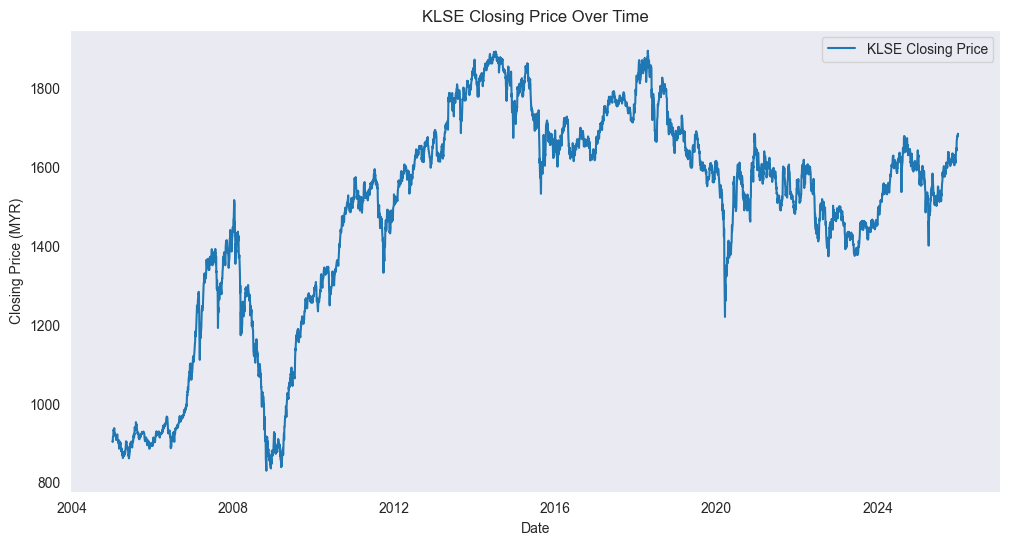

In [12]:
# Plot the closing price over time
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='KLSE Closing Price')
plt.title('KLSE Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (MYR)')
plt.legend()
plt.grid()
plt.show()

# Step 5 — Target Creation

Create the binary target variable. The target is 1 when the next trading day's Close is greater than the current day's Close, otherwise 0. Drop the last row which has no next-day label.

In [13]:
# Create target variable
# 1 = Next trading day closing price is higher than current day closing price
# 0 = Next trading day closing price is lower than or equal to current day closing price

df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# Remove the last row because there is no next trading day closing price
df = df.dropna()

# Check target result
print(df[["Close", "Target"]].head())
print(df[["Close", "Target"]].tail())

# Check class distribution
print(df["Target"].value_counts())

Price            Close Target
Ticker           ^KLSE       
Date                         
2005-01-03  903.840027      0
2005-01-04  902.489990      1
2005-01-05  907.960022      1
2005-01-06  910.419983      1
2005-01-07  916.280029      1
Price             Close Target
Ticker            ^KLSE       
Date                          
2025-12-24  1678.310059      0
2025-12-26  1677.099976      1
2025-12-29  1680.989990      1
2025-12-30  1684.530029      0
2025-12-31  1680.109985      0
Target
1    2677
0    2474
Name: count, dtype: int64


# Step 6 — Feature Selection & Scaling

Select input features for the model. Here we use common OHLCV features: Open, High, Low, Close and Volume. Then normalize the features to [0,1] with MinMaxScaler.

In [14]:
# Select input features for LSTM model
features = ["Open", "High", "Low", "Close", "Volume"]

X = df[features]
y = df["Target"]

# Display selected features
print(X.head())
print(y.head())

# Check feature shape
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Price             Open        High         Low       Close     Volume
Ticker           ^KLSE       ^KLSE       ^KLSE       ^KLSE      ^KLSE
Date                                                                 
2005-01-03  907.020020  907.020020  897.130005  903.840027          0
2005-01-04  900.679993  904.440002  897.770020  902.489990          0
2005-01-05  901.700012  908.859985  901.700012  907.960022          0
2005-01-06  907.950012  912.080017  907.010010  910.419983          0
2005-01-07  910.900024  918.559998  909.840027  916.280029  102465200
Date
2005-01-03    0
2005-01-04    1
2005-01-05    1
2005-01-06    1
2005-01-07    1
Name: Target, dtype: int64
Feature shape: (5151, 5)
Target shape: (5151,)


In [15]:
from sklearn.preprocessing import MinMaxScaler

# Normalise the input features into range 0 to 1
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

# Check scaled data
print(X_scaled[:5])
print("Scaled feature shape:", X_scaled.shape)

[[0.07189869 0.06549589 0.08791348 0.06983688 0.        ]
 [0.06594623 0.06305855 0.08850044 0.06857015 0.        ]
 [0.06690389 0.0672341  0.09210465 0.07370262 0.        ]
 [0.07277183 0.07027606 0.09697447 0.07601077 0.        ]
 [0.07554151 0.07639768 0.09956988 0.08150919 0.10530137]]
Scaled feature shape: (5151, 5)


# Step 7 — Sequence Creation for LSTM

Create time-series sequences for LSTM input. We use a lookback window of 60 trading days (time_steps = 60). The function below converts the scaled feature matrix and labels into (samples, time_steps, features) and corresponding labels.

In [16]:
import numpy as np

# Function to create LSTM sequences
def create_sequences(X, y, time_steps=60):
    Xs, ys = [], []

    for i in range(time_steps, len(X)):
        Xs.append(X[i-time_steps:i])
        ys.append(y.iloc[i])

    return np.array(Xs), np.array(ys)


# Use previous 60 trading days to predict next trading day movement
time_steps = 60

X_seq, y_seq = create_sequences(X_scaled, y, time_steps)

print("X sequence shape:", X_seq.shape)
print("y sequence shape:", y_seq.shape)

X sequence shape: (5091, 60, 5)
y sequence shape: (5091,)


# Step 8 — Train / Test Split

Split sequences into training and testing sets. We use an 80/20 split (no random shuffle to preserve time order). This is important for time-series forecasting/classification to avoid look-ahead bias.

In [17]:
# Split data into training and testing sets
# 80% training data, 20% testing data

train_size = int(len(X_seq) * 0.8)

X_train = X_seq[:train_size]
X_test = X_seq[train_size:]

y_train = y_seq[:train_size]
y_test = y_seq[train_size:]

# Check data shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4072, 60, 5)
X_test shape: (1019, 60, 5)
y_train shape: (4072,)
y_test shape: (1019,)


# Step 9 — Model Building

Build an LSTM-based Keras sequential model for binary classification. The architecture below is a simple baseline: two LSTM layers with dropout and a sigmoid output neuron.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build LSTM model
model = Sequential()

# First LSTM layer
model.add(LSTM(
    units=64,
    return_sequences=True,
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(
    units=32,
    return_sequences=False
))
model.add(Dropout(0.2))

# Output layer for binary classification
model.add(Dense(1, activation="sigmoid"))

# Display model architecture
model.summary()

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

# Step 10 — Compile & Train

Compile the model with Adam optimizer and binary cross-entropy loss. Accuracy is used as a simple performance metric; consider adding AUC for imbalanced datasets. Then train the model.

In [19]:
# Compile the LSTM model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [20]:
# Train the LSTM model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5281 - loss: 0.6932 - val_accuracy: 0.5166 - val_loss: 0.6926
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5278 - loss: 0.6921 - val_accuracy: 0.4957 - val_loss: 0.6933
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5296 - loss: 0.6920 - val_accuracy: 0.4957 - val_loss: 0.7038
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5272 - loss: 0.6924 - val_accuracy: 0.4957 - val_loss: 0.6951
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5241 - loss: 0.6924 - val_accuracy: 0.4957 - val_loss: 0.6954
Epoch 6/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5321 - loss: 0.6912 - val_accuracy: 0.4957 - val_loss: 0.6946
Epoch 7/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5348 - loss: 0.6915 - val_accuracy: 0.4957 - val_loss: 0.6953
Epoch 8/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5312 - loss: 0.6909 - val_accu

# Step 11 — Evaluation & Visualization

Plot training/validation accuracy and loss to inspect training behavior for signs of overfitting or underfitting. After training, make predictions on the test set and calculate evaluation metrics.

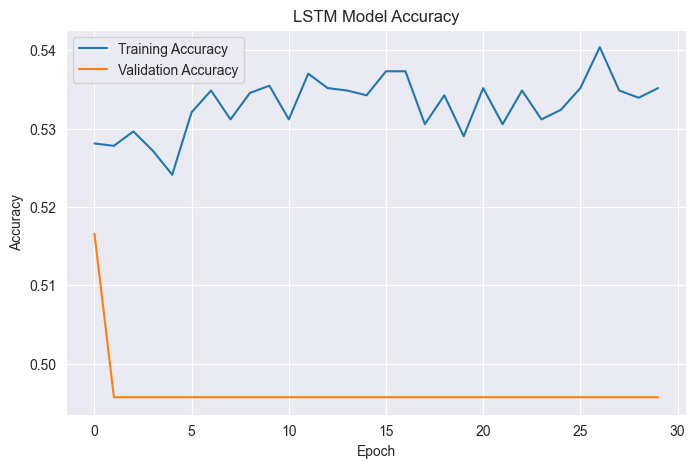

In [21]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

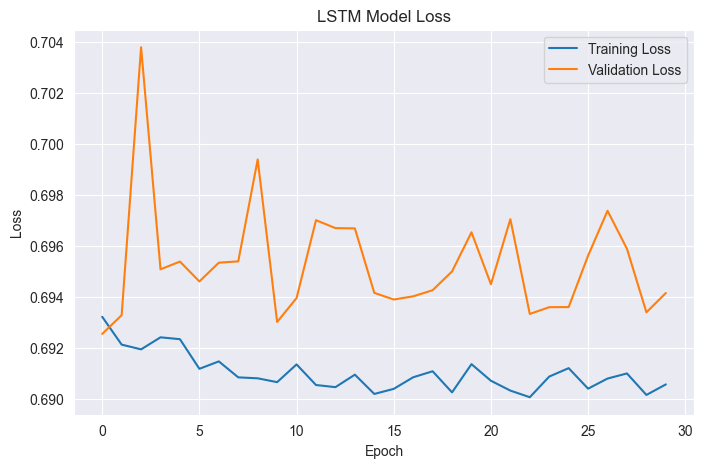

In [22]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Make predictions on the test set and convert predicted probabilities to class labels using a 0.5 threshold. You can change the threshold to tune precision/recall trade-offs.

In [23]:
# Make predictions on the test dataset
y_pred_prob = model.predict(X_test)

# Convert prediction probabilities into class labels
# If probability is greater than 0.5, classify as 1
# Otherwise, classify as 0
y_pred = (y_pred_prob > 0.5).astype(int)

# Display first 10 prediction probabilities
print("First 10 prediction probabilities:")
print(y_pred_prob[:10])

# Display first 10 predicted classes
print("\nFirst 10 predicted classes:")
print(y_pred[:10])

# Display first 10 actual classes
print("\nFirst 10 actual classes:")
print(y_test[:10])

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
First 10 prediction probabilities:
[[0.5257081 ]
 [0.52609897]
 [0.5265169 ]
 [0.52691686]
 [0.5272795 ]
 [0.52764785]
 [0.527987  ]
 [0.52814007]
 [0.52827436]
 [0.52839494]]

First 10 predicted classes:
[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]

First 10 actual classes:
[1 1 0 0 0 1 0 1 1 0]


Prepare predictions and evaluate model performance using accuracy, precision, recall and F1. The notebook uses zero_division=0 in metrics to avoid exceptions for empty predicted classes.

In [24]:
# Flatten predicted labels for evaluation
y_pred = y_pred.flatten()

# Check shapes
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Print results
print("Model Evaluation Results")
print("------------------------")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

y_test shape: (1019,)
y_pred shape: (1019,)
Model Evaluation Results
------------------------
Accuracy: 0.492639842983317
Precision: 0.492639842983317
Recall: 1.0
F1-score: 0.6600920447074293

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       517
           1       0.49      1.00      0.66       502

    accuracy                           0.49      1019
   macro avg       0.25      0.50      0.33      1019
weighted avg       0.24      0.49      0.33      1019


Confusion Matrix:
[[  0 517]
 [  0 502]]


Visualize the confusion matrix and compare actual vs predicted movements for a subset of test samples.

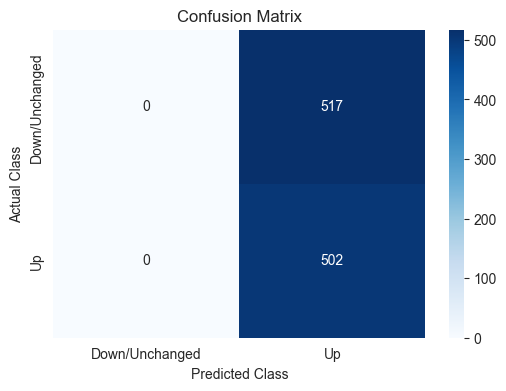

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Down/Unchanged", "Up"],
    yticklabels=["Down/Unchanged", "Up"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

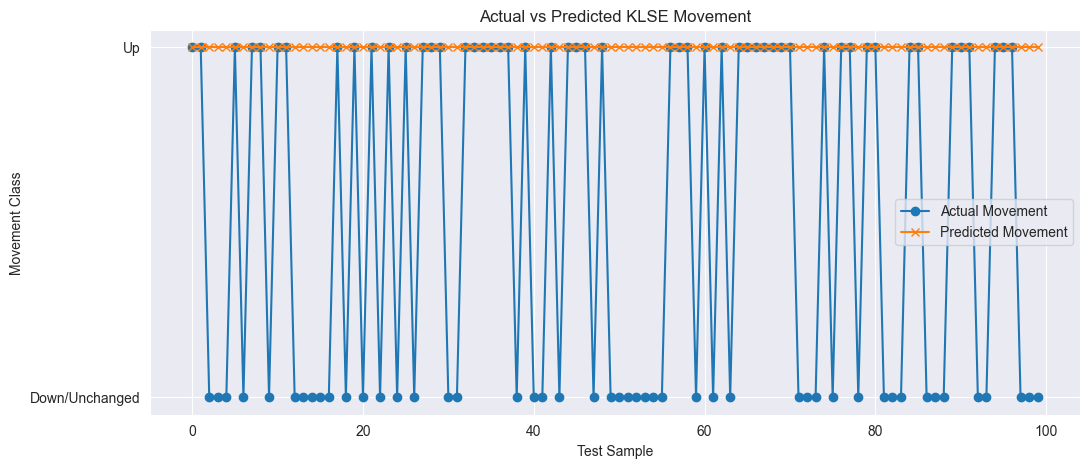

In [26]:
# Plot actual vs predicted movement for first 100 test samples
plt.figure(figsize=(12, 5))
plt.plot(y_test[:100], label="Actual Movement", marker="o")
plt.plot(y_pred[:100], label="Predicted Movement", marker="x")

plt.title("Actual vs Predicted KLSE Movement")
plt.xlabel("Test Sample")
plt.ylabel("Movement Class")
plt.yticks([0, 1], ["Down/Unchanged", "Up"])
plt.legend()
plt.grid(True)
plt.show()

# Step 12 — Save Results & Next Steps

Save the trained model and evaluation results (evaluation metrics, prediction results, confusion matrix) to the project's Result folder so outputs can be reviewed and reused. Also includes suggestions for next steps.

In [27]:
# Save the trained LSTM model
model.save("./Result/KLSE_LSTM_model.h5")

print("Model saved successfully as KLSE_LSTM_model.h5")

Model saved successfully as KLSE_LSTM_model.h5


In [28]:
# Save evaluation metrics into a dictionary
evaluation_results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

# Convert to DataFrame
evaluation_df = pd.DataFrame([evaluation_results])

# Save as CSV
evaluation_df.to_csv("./Result/KLSE_LSTM_evaluation_results.csv", index=False)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [29]:
# Save actual and predicted results
prediction_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

# Save as CSV
prediction_results.to_csv("./Result/KLSE_LSTM_prediction_results.csv", index=False)

print("Prediction results saved successfully.")

Prediction results saved successfully.


In [30]:
# Save confusion matrix as CSV
confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Actual Down/Unchanged", "Actual Up"],
    columns=["Predicted Down/Unchanged", "Predicted Up"]
)

confusion_matrix_df.to_csv("./Result/KLSE_LSTM_confusion_matrix.csv")

print("Confusion matrix saved successfully.")

Confusion matrix saved successfully.
